In [0]:
# 1. IMPORTS
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import functions as F

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [0]:
# 2. CONFIG
TABLE_NAME = "workspace.instagram.instagram_extract_data_v_3"
RANDOM_STATE = 42
# Standard rule of thumb:
# caliper = 0.2 * std(logit(propensity score))
CALIPER_MULTIPLIER = 0.9
# Optional: use sample for debugging
USE_SAMPLE = False
SAMPLE_N = 50000

In [0]:
# 3. LOAD DATA
df_spark = spark.table(TABLE_NAME)
if USE_SAMPLE:
    df_spark = df_spark.limit(SAMPLE_N)

df = df_spark.toPandas().copy()
print("Data loaded successfully")
print("Shape:", df.shape)
print("\nPreview:")
display(df.head())

Data loaded successfully
Shape: (100000, 54)

Preview:


user_id,age,gender,location_tier,device_type,account_age_days,is_creator,follower_count_band,language_pref,past_engagement_score,avg_daily_time_spent_min,avg_sessions_per_day,active_days_last_30,historical_ctr,historical_cvr,historical_save_rate,historical_share_rate,past_purchases_count,preferred_content_type,historical_video_watch_rate,historical_ad_engagement_rate,true_propensity,treatment_flag,campaign_id,ad_format,campaign_objective,creative_theme,cta_type,discount_flag,personalization_flag,placement_quality_score,hour_bucket,day_of_week,is_weekend,auction_competitiveness,cost_per_impression,impressions,reach,frequency,clicks,likes,comments,shares,saves,profile_visits,video_views,avg_watch_time_sec,landing_page_views,conversion_prob_latent,conversions,add_to_cart,revenue,time_to_convert_min,group_label
0,56,Male,Tier3,Android,1851,0,Low,Hindi,47.221247362569500,39.226017587120920,2.5436390166412430,22,0.027807313001519860,0.0179810609685922000,0.011344853744961953,0.0114219779910295410,0,Feed,0.44832902818332710,0.035698462464235324,0.050527212454546895,0,Camp_B,Reel,Traffic,Lifestyle,Shop Now,1,0,0.52611557518854660,Evening,Mon,0,0.391452872649634130,0.0185276042002003420,29,26,1.1153846153846154,2,12,0,2,3,1,13,32.2700811380586600,2,0.016859445744634355,0,0,0E-16,null,Control
1,46,Female,Tier2,iOS,1906,1,Low,Hindi,53.628004139051010,50.136434241890754,2.9090505494058334,22,0.036551984772101066,0.0172793514126130080,0.020207778973479355,0.0118099043270579100,1,Reel,0.38548591179464414,0.042435354998116875,0.082895535773053490,0,Camp_B,Feed,Awareness,UGC,Learn More,1,1,0.41072219264409170,Morning,Sun,1,0.582320021969901600,0.0169268546752867170,33,25,1.3200000000000000,3,11,2,1,4,0,14,31.7788186354596930,1,0.026830404389953377,0,0,0E-16,null,Control
2,32,Male,Tier3,Android,1115,0,Low,Tamil,43.559289805692580,43.885266797058115,2.0758501180321560,18,0.031517022672127350,0.0159907283754884500,0.017594059009578382,0.0098276063550271250,0,Story,0.37374131460355703,0.036847280418297120,0.031791042476430930,0,Camp_B,Carousel,Traffic,Lifestyle,Sign Up,0,0,0.53420796356520310,Evening,Sat,1,0.513181455513167700,0.0190582816962745100,22,15,1.4666666666666666,1,5,2,3,4,0,14,18.6198912986014380,1,0.016160486732534434,0,0,0E-16,null,Control
3,25,Male,Tier2,Android,1560,0,Low,Tamil,49.476851087883330,54.951579910132350,2.3862473044634376,21,0.030691132740128597,0.0148301590331351080,0.017909000344826547,0.0088788524905082330,0,Reel,0.40802514265843050,0.038152473065200340,0.041759502501747490,0,Camp_C,Reel,Conversion,Lifestyle,Learn More,1,1,0.35548293266326030,Night,Fri,0,0.572276951051262700,0.0258487349324747380,21,16,1.3125000000000000,1,9,4,0,2,1,7,33.0288916140230000,1,0.022602436376481707,0,0,0E-16,null,Control
4,38,Male,Tier3,Android,927,0,High,English,56.060770155689470,58.254233569980930,3.1838385248207260,19,0.033676630946453700,0.0177409207940187050,0.019671295233881933,0.0136671176427728930,0,Story,0.38566699295302910,0.046839438232036770,0.070668060594261490,0,Camp_A,Feed,Awareness,Offer,Sign Up,0,0,0.41151374498107357,Evening,Thu,0,0.623646972433834000,0.0156071290469612930,32,22,1.4545454545454546,0,7,0,2,7,0,7,38.4440337705984940,0,0.018445757043904480,0,0,0E-16,null,Control


In [0]:
# 4. BASIC CHECKS
required_cols = ["user_id", "treatment_flag", "conversions"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")
print("\nTreatment split:")
display(
    df["treatment_flag"]
    .value_counts(dropna=False)
    .rename_axis("treatment_flag")
    .reset_index(name="count")
)
print("\nRaw conversion summary:")
raw_conv = (
    df.groupby("treatment_flag")["conversions"]
    .agg(["count", "mean", "sum"])
    .reset_index()
    .rename(columns={"mean": "conversion_rate", "sum": "total_conversions"})
)
display(raw_conv.round(4))


Treatment split:


treatment_flag,count
0,94600
1,5400



Raw conversion summary:


treatment_flag,count,conversion_rate,total_conversions
0,94600,0.024,2269
1,5400,0.0344,186


In [0]:
# 5. SELECT TRUE BASELINE / PRE-TREATMENT VARIABLES ONLY

candidate_match_cols = [
    "age",
    "gender",
    "location_tier",
    "device_type",
    "account_age_days",
    "is_creator",
    "follower_count_band",
    "language_pref",
    "past_engagement_score"
]

match_cols = [c for c in candidate_match_cols if c in df.columns]

if len(match_cols) == 0:
    raise ValueError("No baseline matching columns found in the table.")

print("\nMatching columns used:")
print(match_cols)

work_df = df[["user_id", "treatment_flag", "conversions"] + match_cols].copy()

before_drop = len(work_df)
work_df = work_df.dropna(subset=match_cols).reset_index(drop=True)
after_drop = len(work_df)

print(f"\nRows before dropna: {before_drop}")
print(f"Rows after dropna : {after_drop}")
print(f"Rows dropped      : {before_drop - after_drop}")


Matching columns used:
['age', 'gender', 'location_tier', 'device_type', 'account_age_days', 'is_creator', 'follower_count_band', 'language_pref', 'past_engagement_score']

Rows before dropna: 100000
Rows after dropna : 100000
Rows dropped      : 0


In [0]:
# 6. IDENTIFY NUMERIC / CATEGORICAL COLUMNS
numeric_cols = work_df[match_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in match_cols if c not in numeric_cols]

print("\nNumeric baseline columns:")
print(numeric_cols)

print("\nCategorical baseline columns:")
print(categorical_cols)


Numeric baseline columns:
['age', 'account_age_days', 'is_creator']

Categorical baseline columns:
['gender', 'location_tier', 'device_type', 'follower_count_band', 'language_pref', 'past_engagement_score']


In [0]:
# 7. PREPROCESSOR
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [0]:
# 8. LOGISTIC PROPENSITY MODEL
X = work_df[match_cols].copy()
y = work_df["treatment_flag"].copy()
ps_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])
ps_model.fit(X, y)
work_df["propensity_score"] = ps_model.predict_proba(X)[:, 1]
# AUC
auc = roc_auc_score(y, work_df["propensity_score"])
print(f"\nLogistic Propensity Model AUC: {auc:.4f}")


Logistic Propensity Model AUC: 0.9997



Propensity score summary overall:


metric,value
count,100000.0
mean,0.054
std,0.0199
min,0.0295
25%,0.0431
50%,0.0496
75%,0.0577
max,0.3225



Propensity score summary by treatment:


treatment_flag,count,mean,std,min,25%,50%,75%,max
0,94600.0,0.0501,0.0102,0.0295,0.0427,0.0489,0.056,0.2792
1,5400.0,0.1231,0.0225,0.0725,0.1067,0.1206,0.137,0.3225


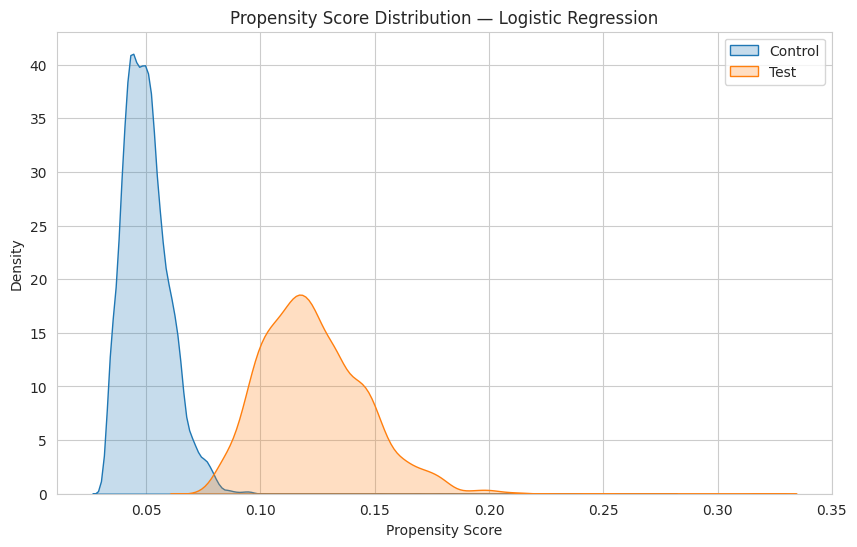

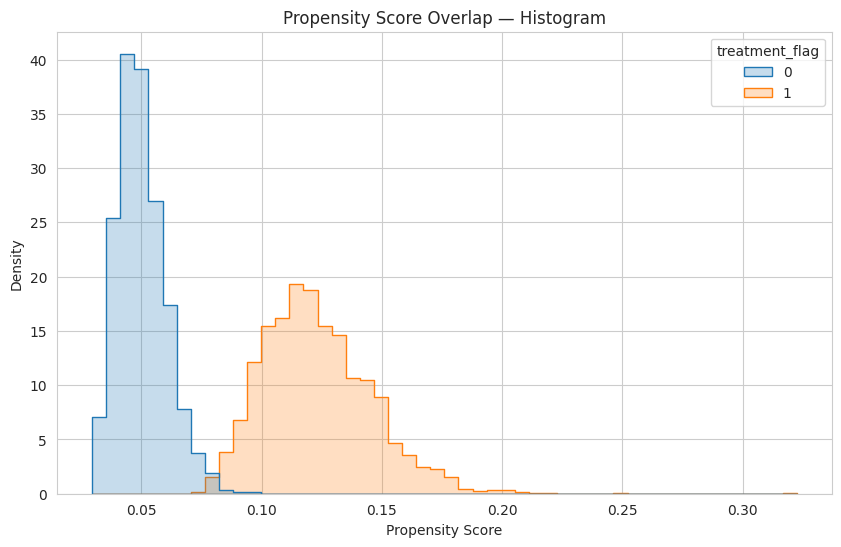

In [0]:
# 9. PROPENSITY SCORE DIAGNOSTICS
print("\nPropensity score summary overall:")
ps_summary = (
    work_df["propensity_score"]
    .describe()
    .reset_index()
)
ps_summary.columns = ["metric", "value"]
display(ps_summary.round(4))
print("\nPropensity score summary by treatment:")
ps_group_summary = (
    work_df.groupby("treatment_flag")["propensity_score"]
    .describe()
    .reset_index()
)
display(ps_group_summary.round(4))

# KDE overlap plot
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=work_df[work_df["treatment_flag"] == 0],
    x="propensity_score",
    label="Control",
    fill=True
)
sns.kdeplot(
    data=work_df[work_df["treatment_flag"] == 1],
    x="propensity_score",
    label="Test",
    fill=True
)
plt.title("Propensity Score Distribution — Logistic Regression")
plt.xlabel("Propensity Score")
plt.ylabel("Density")
plt.legend()
plt.show()

# Histogram overlap plot
plt.figure(figsize=(10, 6))
sns.histplot(
    data=work_df,
    x="propensity_score",
    hue="treatment_flag",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)
plt.title("Propensity Score Overlap — Histogram")
plt.xlabel("Propensity Score")
plt.ylabel("Density")
plt.show()


Common support bounds
Test PS range    : 0.072467 to 0.322515
Control PS range : 0.029488 to 0.279246
Common support   : 0.072467 to 0.279246

Rows after common support trimming: 8107
Treatment split after trimming:


treatment_flag,count
1,5399
0,2708


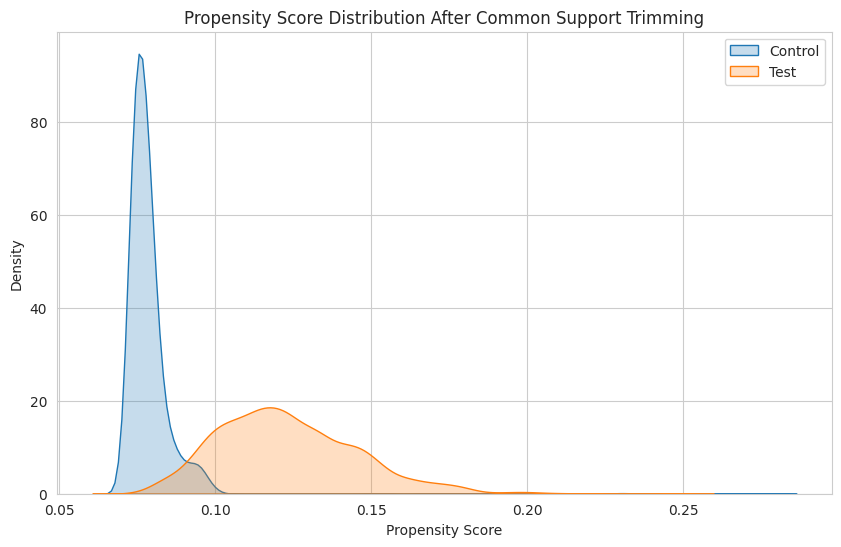

In [0]:
# 10. COMMON SUPPORT TRIMMING
test_all = work_df[work_df["treatment_flag"] == 1].copy()
control_all = work_df[work_df["treatment_flag"] == 0].copy()

test_min = test_all["propensity_score"].min()
test_max = test_all["propensity_score"].max()

control_min = control_all["propensity_score"].min()
control_max = control_all["propensity_score"].max()

lower_bound = max(test_min, control_min)
upper_bound = min(test_max, control_max)

print("\nCommon support bounds")
print(f"Test PS range    : {test_min:.6f} to {test_max:.6f}")
print(f"Control PS range : {control_min:.6f} to {control_max:.6f}")
print(f"Common support   : {lower_bound:.6f} to {upper_bound:.6f}")

if lower_bound >= upper_bound:
    raise ValueError("No common support found. Revisit feature set or data generation.")

work_df_cs = work_df[
    (work_df["propensity_score"] >= lower_bound) &
    (work_df["propensity_score"] <= upper_bound)
].copy().reset_index(drop=True)

print("\nRows after common support trimming:", len(work_df_cs))
print("Treatment split after trimming:")
display(
    work_df_cs["treatment_flag"]
    .value_counts()
    .rename_axis("treatment_flag")
    .reset_index(name="count")
)

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=work_df_cs[work_df_cs["treatment_flag"] == 0],
    x="propensity_score",
    label="Control",
    fill=True
)
sns.kdeplot(
    data=work_df_cs[work_df_cs["treatment_flag"] == 1],
    x="propensity_score",
    label="Test",
    fill=True
)
plt.title("Propensity Score Distribution After Common Support Trimming")
plt.xlabel("Propensity Score")
plt.ylabel("Density")
plt.legend()
plt.show()

In [0]:
# 11. CALCULATE CALIPER
eps = 1e-6
work_df_cs["propensity_score_clipped"] = work_df_cs["propensity_score"].clip(eps, 1 - eps)
work_df_cs["logit_ps"] = np.log(
    work_df_cs["propensity_score_clipped"] / (1 - work_df_cs["propensity_score_clipped"])
)
caliper = CALIPER_MULTIPLIER * work_df_cs["logit_ps"].std()
print("\nCaliper setup")
print(f"Caliper multiplier used : {CALIPER_MULTIPLIER}")
print(f"Std of logit(PS)        : {work_df_cs['logit_ps'].std():.6f}")
print(f"Final caliper           : {caliper:.6f}")


Caliper setup
Caliper multiplier used : 0.9
Std of logit(PS)        : 0.289554
Final caliper           : 0.260599


In [0]:
# 12. SPLIT TEST / CONTROL AFTER COMMON SUPPORT
test_df = work_df_cs[work_df_cs["treatment_flag"] == 1].copy().reset_index(drop=True)
control_df = work_df_cs[work_df_cs["treatment_flag"] == 0].copy().reset_index(drop=True)
print("\nCommon support sample sizes")
print("Test   :", len(test_df))
print("Control:", len(control_df))


Common support sample sizes
Test   : 5399
Control: 2708


In [0]:
# 13. 1:1 CALIPER MATCHING WITHOUT REPLACEMENT
test_df = test_df.sort_values("propensity_score").reset_index(drop=True)
control_pool = control_df.sort_values("propensity_score").reset_index(drop=True).copy()

matched_pairs = []

for _, test_row in test_df.iterrows():
    control_pool["distance_logit_ps"] = np.abs(control_pool["logit_ps"] - test_row["logit_ps"])
    eligible_controls = control_pool[control_pool["distance_logit_ps"] <= caliper]
    if eligible_controls.empty:
        continue

    best_idx = eligible_controls["distance_logit_ps"].idxmin()
    best_control = control_pool.loc[best_idx]

    matched_pairs.append({
        "test_user_id": test_row["user_id"],
        "control_user_id": best_control["user_id"],
        "test_propensity_score": test_row["propensity_score"],
        "control_propensity_score": best_control["propensity_score"],
        "distance_ps": abs(test_row["propensity_score"] - best_control["propensity_score"]),
        "distance_logit_ps": abs(test_row["logit_ps"] - best_control["logit_ps"])
    })

    # Remove matched control => without replacement
    control_pool = control_pool.drop(index=best_idx)
matched_pairs_df = pd.DataFrame(matched_pairs)

print("\nMatching complete")
matched_test_count = matched_pairs_df["test_user_id"].nunique() if len(matched_pairs_df) > 0 else 0
matched_control_count = matched_pairs_df["control_user_id"].nunique() if len(matched_pairs_df) > 0 else 0

print("Total test users      :", len(test_df))
print("Matched test users    :", matched_test_count)
print("Matched control users :", matched_control_count)
print("Unmatched test users  :", len(test_df) - matched_test_count)
print("Matched pair rows     :", len(matched_pairs_df))

if len(matched_pairs_df) > 0:
    display(matched_pairs_df.head(10))
else:
    raise ValueError("No matches found within caliper even after common support trimming.")


Matching complete
Total test users      : 5399
Matched test users    : 814
Matched control users : 814
Unmatched test users  : 4585
Matched pair rows     : 814


test_user_id,control_user_id,test_propensity_score,control_propensity_score,distance_ps,distance_logit_ps
45609,3359,0.07246702639847423,0.07246710566859305,7.927011881625479E-8,1.1793412566518668E-6
36063,511,0.0744201088334184,0.0744198132846812,2.9554873720583075E-7,4.290675688967127E-6
18357,58314,0.0755770470316746,0.07557711136526324,6.433358863688898E-8,9.20824718253499E-7
46678,4107,0.07561889401576138,0.07562045103252159,1.557016760203589E-6,2.227449162717221E-5
2227,8143,0.07582626733763446,0.07583098614650419,4.71880886972198E-6,6.733590234953013E-5
74822,66277,0.07633468715416449,0.0763330623743446,1.6247798198809615E-6,2.304422950594187E-5
75033,63547,0.0764454515576953,0.07644503819829994,4.133593953653536E-7,5.85483537784981E-6
36204,16524,0.07675169117578282,0.07674968393557194,2.0072402108772813E-6,2.832683683573478E-5
53908,49207,0.07706311320097155,0.07706355377103621,4.4057006466646786E-7,6.1943436251432615E-6
45015,47678,0.07709568525568528,0.07710330030098973,7.615045304457113E-6,1.0702028080666892E-4


In [0]:
# 14. BUILD MATCHED DATASET
matched_test_df = test_df.merge(
    matched_pairs_df[["test_user_id"]],
    left_on="user_id",
    right_on="test_user_id",
    how="inner"
).drop(columns=["test_user_id"])

matched_control_df = control_df.merge(
    matched_pairs_df[["control_user_id"]],
    left_on="user_id",
    right_on="control_user_id",
    how="inner"
).drop(columns=["control_user_id"])

matched_df = pd.concat([matched_test_df, matched_control_df], axis=0).reset_index(drop=True)

print("\nMatched dataset shape:", matched_df.shape)
print("\nMatched treatment split:")
display(
    matched_df["treatment_flag"]
    .value_counts()
    .rename_axis("treatment_flag")
    .reset_index(name="count")
)


Matched dataset shape: (1628, 15)

Matched treatment split:


treatment_flag,count
1,814
0,814



Sample summary:


dataset,group,count
original,control,94600
original,test,5400
common_support,control,2708
common_support,test,5399
matched,control,814
matched,test,814


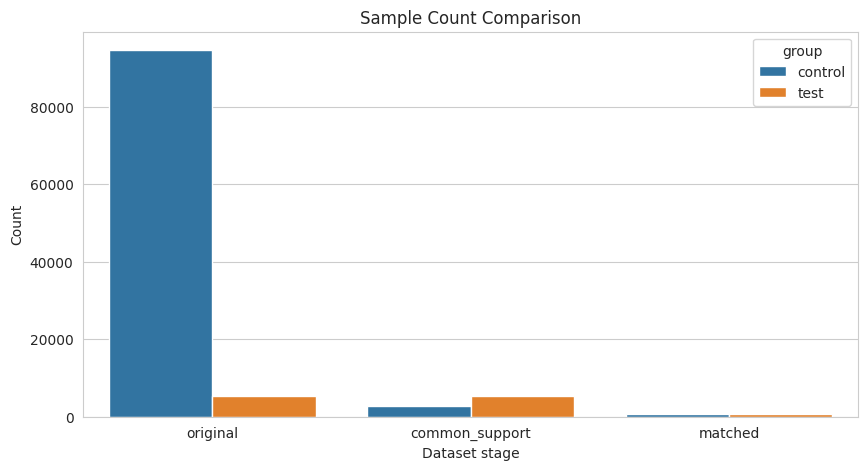

In [0]:
# 15. SAMPLE COUNT COMPARISON
sample_summary = pd.DataFrame({
    "dataset": ["original", "original", "common_support", "common_support", "matched", "matched"],
    "group": ["control", "test", "control", "test", "control", "test"],
    "count": [
        (work_df["treatment_flag"] == 0).sum(),
        (work_df["treatment_flag"] == 1).sum(),
        (work_df_cs["treatment_flag"] == 0).sum(),
        (work_df_cs["treatment_flag"] == 1).sum(),
        (matched_df["treatment_flag"] == 0).sum(),
        (matched_df["treatment_flag"] == 1).sum(),
    ]
})
print("\nSample summary:")
display(sample_summary)
plt.figure(figsize=(10, 5))
sns.barplot(data=sample_summary, x="dataset", y="count", hue="group")
plt.title("Sample Count Comparison")
plt.xlabel("Dataset stage")
plt.ylabel("Count")
plt.show()


Balance comparison:


feature,pre_smd,abs_pre_smd,cs_smd,abs_cs_smd,post_smd,abs_post_smd
account_age_days,0.1051,0.1051,-0.9203,0.9203,-2.2716,2.2716
is_creator,0.0948,0.0948,-1.0919,1.0919,-2.363,2.363
age,-0.0048,0.0048,0.032,0.032,0.0404,0.0404


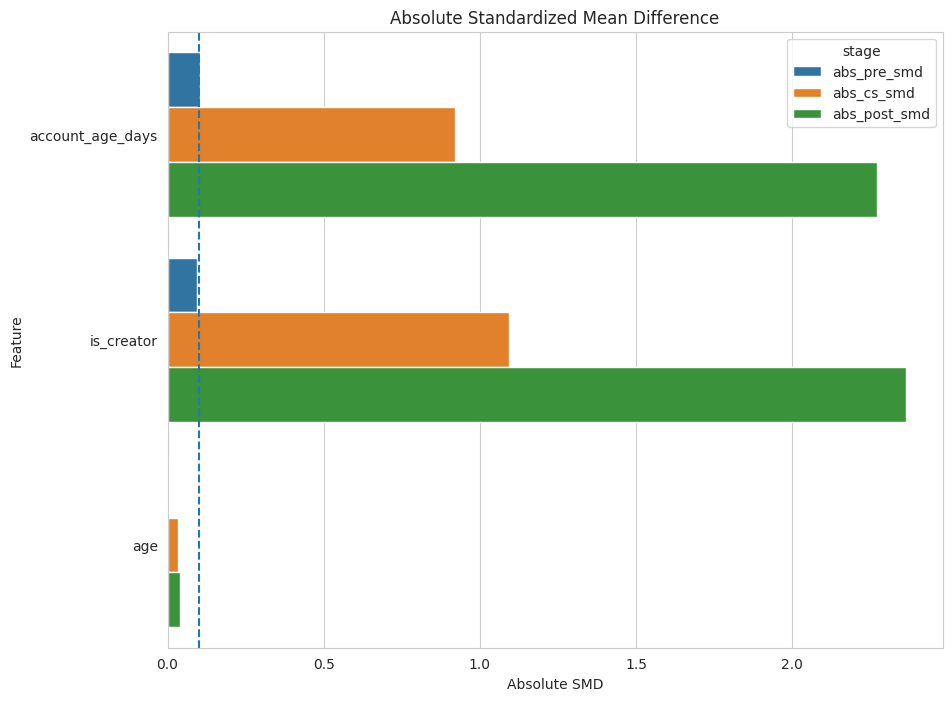

In [0]:
# 16. BALANCE CHECK — STANDARDIZED MEAN DIFFERENCE (NUMERIC)
def calc_numeric_smd(data, treatment_col, feature_cols):
    treated = data[data[treatment_col] == 1]
    control = data[data[treatment_col] == 0]
    rows = []
    for col in feature_cols:
        mean_t = treated[col].mean()
        mean_c = control[col].mean()
        std_t = treated[col].std()
        std_c = control[col].std()
        pooled_std = np.sqrt((std_t**2 + std_c**2) / 2)
        if pooled_std == 0 or np.isnan(pooled_std):
            smd = 0.0
        else:
            smd = (mean_t - mean_c) / pooled_std
        rows.append({
            "feature": col,
            "treated_mean": mean_t,
            "control_mean": mean_c,
            "smd": smd,
            "abs_smd": abs(smd)
        })
    return pd.DataFrame(rows)

balance_pre = calc_numeric_smd(work_df, "treatment_flag", numeric_cols)[["feature", "smd", "abs_smd"]]
balance_pre = balance_pre.rename(columns={"smd": "pre_smd", "abs_smd": "abs_pre_smd"})
balance_cs = calc_numeric_smd(work_df_cs, "treatment_flag", numeric_cols)[["feature", "smd", "abs_smd"]]
balance_cs = balance_cs.rename(columns={"smd": "cs_smd", "abs_smd": "abs_cs_smd"})
balance_post = calc_numeric_smd(matched_df, "treatment_flag", numeric_cols)[["feature", "smd", "abs_smd"]]
balance_post = balance_post.rename(columns={"smd": "post_smd", "abs_smd": "abs_post_smd"})
balance_compare = (
    balance_pre
    .merge(balance_cs, on="feature", how="outer")
    .merge(balance_post, on="feature", how="outer")
)

balance_compare = balance_compare.sort_values("abs_pre_smd", ascending=False).reset_index(drop=True)

print("\nBalance comparison:")
display(balance_compare.round(4))

plot_balance = balance_compare.melt(
    id_vars="feature",
    value_vars=["abs_pre_smd", "abs_cs_smd", "abs_post_smd"],
    var_name="stage",
    value_name="abs_smd"
)
plt.figure(figsize=(10, 8))
sns.barplot(data=plot_balance, y="feature", x="abs_smd", hue="stage")
plt.axvline(0.10, linestyle="--")
plt.title("Absolute Standardized Mean Difference")
plt.xlabel("Absolute SMD")
plt.ylabel("Feature")
plt.show()

In [0]:
# 17. CATEGORICAL BALANCE SNAPSHOT
for c in categorical_cols[:8]:
    print(f"\nCategorical balance — {c} (PRE-MATCH)")
    pre_tab = pd.crosstab(work_df[c], work_df["treatment_flag"], normalize="columns") * 100
    display(pre_tab.round(2))

    print(f"Categorical balance — {c} (COMMON SUPPORT)")
    cs_tab = pd.crosstab(work_df_cs[c], work_df_cs["treatment_flag"], normalize="columns") * 100
    display(cs_tab.round(2))

    print(f"Categorical balance — {c} (POST-MATCH)")
    post_tab = pd.crosstab(matched_df[c], matched_df["treatment_flag"], normalize="columns") * 100
    display(post_tab.round(2))


Categorical balance — gender (PRE-MATCH)


0,1
48.08,48.85
51.92,51.15


Categorical balance — gender (COMMON SUPPORT)


0,1
55.21,48.84
44.79,51.16


Categorical balance — gender (POST-MATCH)


...

0,1
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0


Categorical balance — past_engagement_score (COMMON SUPPORT)


0,1
0.04,0.0
0.0,0.02
0.0,0.02
0.0,0.02
0.04,0.0
0.0,0.02
0.0,0.02
0.0,0.02
0.0,0.02
0.04,0.0


Categorical balance — past_engagement_score (POST-MATCH)


0,1
0.0,0.12
0.0,0.12
0.12,0.0
0.0,0.12
0.12,0.0
0.0,0.12
0.0,0.12
0.0,0.12
0.0,0.12
0.0,0.12


In [0]:
# 18. CONVERSION SUMMARY — ORIGINAL / COMMON SUPPORT / MATCHED
def conversion_summary_fn(data, label):
    out = (
        data.groupby("treatment_flag")["conversions"]
        .agg(["count", "mean", "sum"])
        .reset_index()
        .rename(columns={"mean": "conversion_rate", "sum": "total_conversions"})
    )
    out["dataset"] = label
    return out

orig_conv = conversion_summary_fn(work_df, "original")
cs_conv = conversion_summary_fn(work_df_cs, "common_support")
matched_conv = conversion_summary_fn(matched_df, "matched")
print("\nOriginal conversion summary:")
display(orig_conv.round(4))
print("\nCommon support conversion summary:")
display(cs_conv.round(4))
print("\nMatched conversion summary:")
display(matched_conv.round(4))


Original conversion summary:


treatment_flag,count,conversion_rate,total_conversions,dataset
0,94600,0.024,2269,original
1,5400,0.0344,186,original



Common support conversion summary:


treatment_flag,count,conversion_rate,total_conversions,dataset
0,2708,0.0314,85,common_support
1,5399,0.0345,186,common_support



Matched conversion summary:


treatment_flag,count,conversion_rate,total_conversions,dataset
0,814,0.027,22,matched
1,814,0.0283,23,matched


In [0]:
# 19. LIFT SUMMARY
def build_lift_summary(summary_df, dataset_name):
    control_rate = summary_df.loc[summary_df["treatment_flag"] == 0, "conversion_rate"].values[0]
    test_rate = summary_df.loc[summary_df["treatment_flag"] == 1, "conversion_rate"].values[0]
    absolute_lift = test_rate - control_rate
    relative_lift = (test_rate / control_rate - 1) if control_rate > 0 else np.nan
    return pd.DataFrame({
        "dataset": [dataset_name],
        "control_rate": [control_rate],
        "test_rate": [test_rate],
        "absolute_lift": [absolute_lift],
        "relative_lift": [relative_lift]
    })

lift_original = build_lift_summary(orig_conv, "original")
lift_cs = build_lift_summary(cs_conv, "common_support")
lift_matched = build_lift_summary(matched_conv, "matched")
lift_summary = pd.concat([lift_original, lift_cs, lift_matched], axis=0)

print("\nLift summary:")
display(lift_summary.round(4))


Lift summary:


dataset,control_rate,test_rate,absolute_lift,relative_lift
original,0.024,0.0344,0.0105,0.4361
common_support,0.0314,0.0345,0.0031,0.0976
matched,0.027,0.0283,0.0012,0.0455


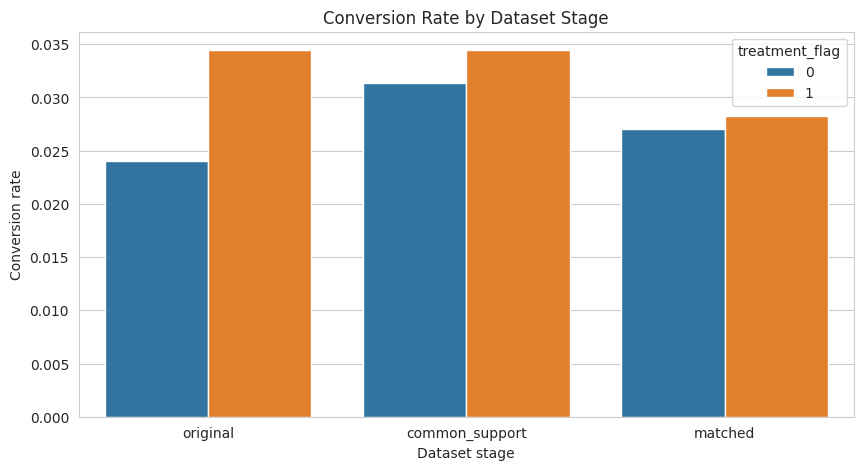

In [0]:
# 20. VISUALIZE CONVERSION RATES
plot_conv = pd.concat([orig_conv, cs_conv, matched_conv], axis=0)
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_conv, x="dataset", y="conversion_rate", hue="treatment_flag")
plt.title("Conversion Rate by Dataset Stage")
plt.xlabel("Dataset stage")
plt.ylabel("Conversion rate")
plt.show()


Match distance summary:


metric,count,mean,std,min,25%,50%,75%,max
distance_ps,814.0,0.009854,0.00865,0.0,2.33E-4,0.011404,0.017395,0.046854
distance_logit_ps,814.0,0.118253,0.099067,1.0E-6,0.00286,0.140929,0.215175,0.260598


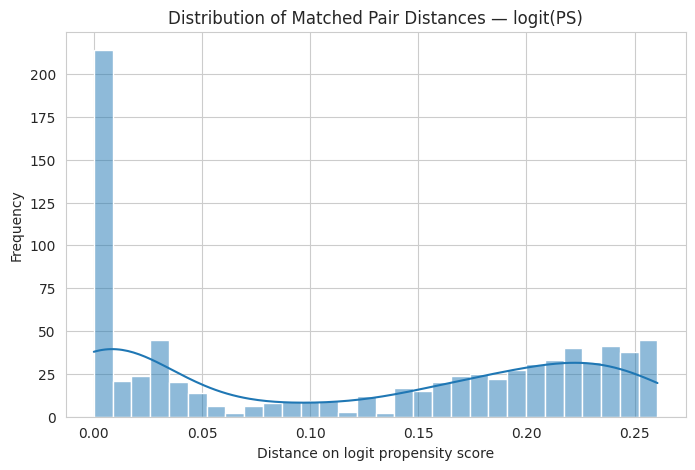

In [0]:
# 21. MATCH DISTANCE DIAGNOSTICS
print("\nMatch distance summary:")
distance_summary = (
    matched_pairs_df[["distance_ps", "distance_logit_ps"]]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(distance_summary.round(6))
plt.figure(figsize=(8, 5))
sns.histplot(matched_pairs_df["distance_logit_ps"], bins=30, kde=True)
plt.title("Distribution of Matched Pair Distances — logit(PS)")
plt.xlabel("Distance on logit propensity score")
plt.ylabel("Frequency")
plt.show()

In [0]:
# 22. LOGISTIC COEFFICIENT SNAPSHOT
try:
    fitted_preprocessor = ps_model.named_steps["preprocess"]
    fitted_model = ps_model.named_steps["model"]
    feature_names = fitted_preprocessor.get_feature_names_out()
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": fitted_model.coef_[0]
    })

    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
    print("\nTop logistic coefficients:")
    display(coef_df.head(25).round(4))

except Exception as e:
    print("Could not extract logistic coefficients:", str(e))


Top logistic coefficients:


feature,coefficient,abs_coefficient
cat__past_engagement_score_100.000000000000000,1.543,1.543
cat__past_engagement_score_58.185076258444646,0.9129,0.9129
cat__past_engagement_score_65.304810673552600,0.9117,0.9117
cat__past_engagement_score_70.015970739915250,0.9111,0.9111
cat__past_engagement_score_63.196119572379715,0.9111,0.9111
cat__past_engagement_score_70.278219568362890,0.911,0.911
cat__past_engagement_score_56.007810873337700,0.9107,0.9107
cat__past_engagement_score_48.511259262646240,0.9104,0.9104
cat__past_engagement_score_68.020901889745700,0.9103,0.9103
cat__past_engagement_score_64.449368811067760,0.9101,0.9101


In [0]:
# 23. SAVE OUTPUTS 
# Full matched analysis dataset with all original columns
matched_analysis_df = df.merge(
    matched_df[["user_id"]],
    on="user_id",
    how="inner"
)
print("\nMatched analysis dataset shape:", matched_analysis_df.shape)


Matched analysis dataset shape: (1628, 54)


In [0]:
# 24. FINAL SUMMARY
print("\nNOTEBOOK 1 COMPLETE")
print("---------------------------")
print("Method                         : Logistic PS + Common Support + Caliper Matching")
print(f"Propensity model AUC           : {auc:.4f}")
print(f"Caliper multiplier             : {CALIPER_MULTIPLIER}")
print(f"Final caliper                  : {caliper:.6f}")
print(f"Original rows                  : {len(work_df)}")
print(f"Common support rows            : {len(work_df_cs)}")
print(f"Matched rows                   : {len(matched_df)}")
print("Matching type                  : 1:1 without replacement")


NOTEBOOK 1 COMPLETE
---------------------------
Method                         : Logistic PS + Common Support + Caliper Matching
Propensity model AUC           : 0.9997
Caliper multiplier             : 0.9
Final caliper                  : 0.260599
Original rows                  : 100000
Common support rows            : 8107
Matched rows                   : 1628
Matching type                  : 1:1 without replacement
